<a href="https://colab.research.google.com/github/mtnleo/Uni_AI_1/blob/main/Guia5_Leonardi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#UNIVERSIDAD ATLANTIDA ARGENTINA
#INTELIGENCIA ARTIFICIAL 1

##PRACTICA 5

###TEMAS
* CLUSTERING
* CALIDAD DE AGRUPAMIENTO
* K-MODAS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

# Cargar dataset
iris = load_iris()
nombre_archivo = '/content/drive/MyDrive/seeds_dataset.xlsx'

##Ejercicios Prácticos
Utilice los códigos del material de consulta (K_Modas.ipynb ,  Calidad_agrupamiento.ipynb) y los conceptos vistos en teoria para resolver los siguientes ejercicios.

## Calidad de Agrupamiento

**Ejercicio 1: Comparar diferentes métricas para elegir k**

1.  Genera un dataset con `make_blobs` usando 3 clusters.
2.  Calcula SSE (metodo del codo) y silueta para k de 2 a 6.
3.  ¿Ambos métodos sugieren el mismo k óptimo? ¿Por qué?

---

**Ejercicio 2: Pureza con diferentes algoritmos**

1.  Usando el dataset Iris, aplica K-Means con k=3.
2.  Calcula la pureza comparando con las etiquetas reales de las flores.
3.  ¿Qué tan bien se alinean los clusters con las especies reales?

---

**Ejercicio 3: Visualización avanzada de silueta**

1.  Explicar el algoritmo de calculo del coeficiente promedio de silueta.
2.  Comparelo com el metodo de Codo.

---




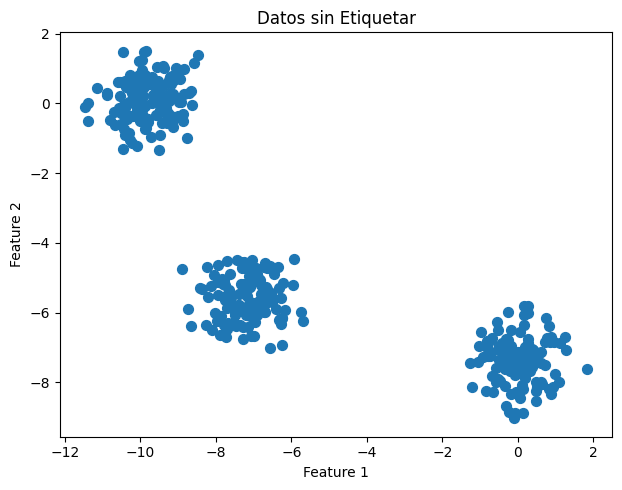

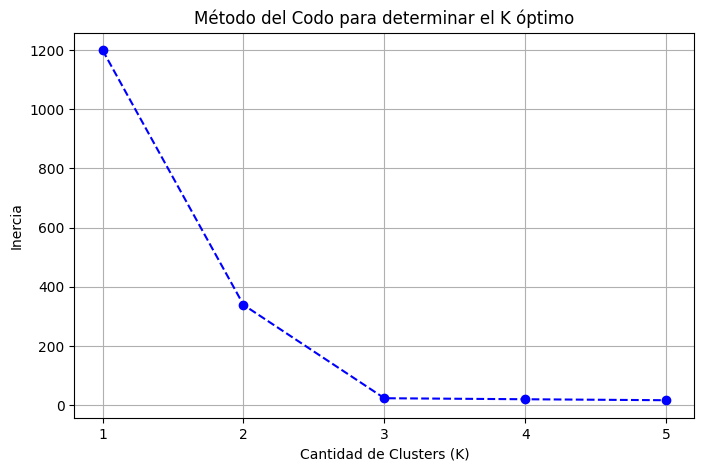

Cálculo con scikit-learn:
Primeros 5 valores de s(i): [np.float64(0.5782), np.float64(0.1944), np.float64(0.3867), np.float64(0.4478), np.float64(0.8995)]
Silueta promedio (sklearn): 0.5351



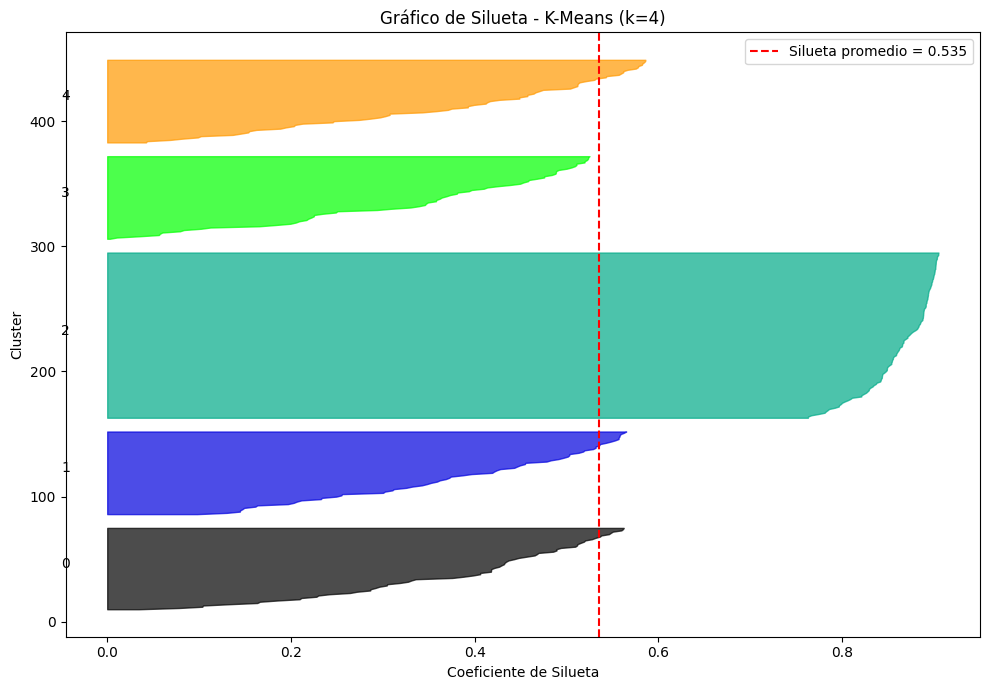

In [7]:
##### Ejercicio 1: Comparar diferentes métricas para elegir k
# 1. Genera un dataset con make_blobs usando 3 clusters.
from sklearn.datasets import make_blobs

X_blobs, y_blobs = make_blobs(n_samples=400, centers=3, cluster_std=0.60, random_state=9)

df_blobs = pd.DataFrame(X_blobs, columns=['Feature1', 'Feature2'])
df_blobs['Cluster_Real'] = y_blobs

###
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=50)
plt.title('Datos sin Etiquetar')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()
###

# 2. Calcula SSE (metodo del codo) y silueta para k de 2 a 6.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples  #Indice de silhouette del agrupamiento e indice silhouette por muestra

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(df_blobs)

inercias = []
valores_k = range(1, 6) # Probamos de 1 a 6 clusters

for k in valores_k:
    # Instanciamos el modelo.
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Entrenamos usando los datos estandarizados (X_std)
    kmeans.fit(X_std)

    # Guardamos la inercia resultante
    inercias.append(kmeans.inertia_)

  # Graficamos los resultados (Método del Codo)
plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercias, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para determinar el K óptimo')
plt.xlabel('Cantidad de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(valores_k)
plt.grid(True)
plt.show()

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
#### SILHOUETTE
y_kmeans = kmeans.fit_predict(X_std) #Etiquetas generadas por K-means


s_sklearn = silhouette_samples(X_std, y_kmeans)
silueta_promedio_sklearn = silhouette_score(X_std, y_kmeans)

print('Cálculo con scikit-learn:')
print('Primeros 5 valores de s(i):', [round(x, 4) for x in s_sklearn[:5]])
print('Silueta promedio (sklearn):', round(silueta_promedio_sklearn, 4))
print()

def grafico_silueta(X, etiquetas, titulo='Gráfico de Silueta'):
    '''Genera un gráfico de silueta para los clusters.'''
    n_clusters = len(np.unique(etiquetas))
    s_vals = silhouette_samples(X, etiquetas)
    s_promedio = silhouette_score(X, etiquetas)

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))

    y_lower = 10
    for i in range(n_clusters):
        # Obtener valores de silueta para el cluster i
        cluster_s_vals = s_vals[etiquetas == i]
        cluster_s_vals.sort()

        y_upper = y_lower + len(cluster_s_vals)

        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, cluster_s_vals,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Etiqueta del cluster
        ax.text(-0.05, y_lower + 0.5 * len(cluster_s_vals), str(i))

        y_lower = y_upper + 10

    ax.axvline(x=s_promedio, color='red', linestyle='--',
               label='Silueta promedio = ' + str(round(s_promedio, 3)))
    ax.set_xlabel('Coeficiente de Silueta')
    ax.set_ylabel('Cluster')
    ax.set_title(titulo)
    ax.legend()

    plt.tight_layout()
    plt.show()


# Generar gráfico para nuestros datos
grafico_silueta(X_std, y_kmeans, 'Gráfico de Silueta - K-Means (k=4)')

# 3. ¿Ambos métodos sugieren el mismo k óptimo? ¿Por qué?

##K-Modas
**Ejercicio 1: Experimentar con el número de clusters**
1.  Modificar el número de clusters (K=2, K=4) y analizar cómo cambian los perfiles.
2. Probar los diferentes métodos de inicialización:
   - init='random'
   - init='Huang'
   - init='Cao'
   ¿Cuál da mejor resultado (menor costo)?
3. Agregar un nuevo atributo: 'Frecuencia_visita' = ['semanal', 'quincenal', 'mensual']
   ¿Cómo cambian los clusters?
4. Predecir el cluster para un nuevo cliente con K-Prototypes:
   Cabello='castaño', Ojos='verde', Piel='clara', Edad=33, Tratamiento_favorito='hidratación'

5. Implementar una métrica de evaluación adicional: silhouette_score adaptada para kmodes.   

In [ ]:
#@title Resuelve aqui tu ejercicio